
# Análise de Dados | Conjunto de Dados Público de E-commerce Brasileiro da Olist

**100.000 Pedidos com informações de produtos, clientes e avaliações**

**Analistas: Nikolas, Davi, Edvan, Samuel, Rômulo, Luís e Fábily**

---

## Sobre o Conjunto de Dados

Bem-vindo! Este é um conjunto de dados público de e-commerce brasileiro com informações sobre pedidos realizados na **Loja Olist**. 

O dataset contém informações de 100 mil pedidos feitos entre **2016 e 2018** em diversos marketplaces no Brasil. Seus recursos permitem visualizar um pedido sob múltiplas perspectivas: 

* **Status do pedido:** Preço, pagamento e desempenho do frete.
* **Localização:** Dados do cliente e geolocalização (CEPs brasileiros relacionados a coordenadas de latitude e longitude).
* **Atributos do produto:** Categorias e características.
* **Avaliações:** Comentários escritos pelos clientes.

> **Anonimização:** Estes são dados comerciais reais. Referências a empresas e parceiros nas avaliações foram substituídas por nomes das grandes casas de **Game of Thrones**.

---

## Contexto

Este conjunto de dados foi gentilmente cedido pela **Olist**, a maior loja de departamentos em marketplaces brasileiros. A Olist conecta pequenas empresas de todo o Brasil a canais de distribuição com um único contrato. Esses comerciantes vendem seus produtos pela Loja Olist e os enviam diretamente aos clientes usando os parceiros logísticos da plataforma. 

Saiba mais em: [www.olist.com](http://www.olist.com)

### Fluxo de Avaliação
Após a compra, o vendedor é notificado para processar o pedido. Assim que o cliente recebe o produto (ou a data estimada se aproxima), ele recebe uma pesquisa de satisfação por e-mail para avaliar a experiência.

---

## Esquema de Dados

Os dados estão divididos em vários conjuntos para melhor organização. Consulte o esquema abaixo ao realizar modelagens ou joins:

![Esquema de Dados Olist](https://i.imgur.com/HRhd2Y0.png)

---

## Agradecimentos

Agradecemos à **Olist** por disponibilizar este conjunto de dados para a comunidade.

Iniciemos nossas análises!
===

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from IPython.display import display
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Criação do diretório de resultados
os.makedirs('results', exist_ok=True)

# Carregamento do Super Dataset
print("Carregando o Super Dataset...")
try:
    path_ds = '../data/processed/olist_super_dataset.csv'
    df = pd.read_csv(path_ds, low_memory=False)
    print(f"Dataset carregado! {df.shape[0]} linhas e {df.shape[1]} colunas.")
except Exception as e:
    print("Erro ao carregar o dataset principal. Tentando carregamento dinâmico...", e)
    path_ds = '../data/processed/olist_super_dataset_dynamic.csv'
    df = pd.read_csv(path_ds, low_memory=False)

Carregando o Super Dataset...
Dataset carregado! 107576 linhas e 22 colunas.


# Parte 1. Introdução e Contexto

In [ ]:
# Verificação do volume e estrutura do dataset
display(df.head(3))
display(df.info())

,order_id,customer_id,order_purchase_timestamp,order_delivered_customer_date,tempo_entrega_dias,atraso_entrega,customer_unique_id,customer_city,customer_state,order_item_id,...,price,freight_value,product_category_name,product_photos_qty,product_description_lenght,seller_city,seller_state,payment_value,review_score,receita_liquida
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-10 21:25:13,8.0,False,7c396fd4830fd04220f754e42b4e5bff,sao paulo,SP,1,...,29.99,8.72,utilidades_domesticas,4.0,268.0,maua,SP,38.71,4.0,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-08-07 15:27:45,13.0,False,af07308b275d755c9edb36a90c618231,barreiras,BA,1,...,118.70,22.76,perfumaria,1.0,178.0,belo horizonte,SP,141.46,4.0,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-17 18:06:29,9.0,False,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,GO,1,...,159.90,19.22,automotivo,1.0,232.0,guariba,SP,179.12,5.0,179.12


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 107576 entries, 0 to 107575
Data columns (total 22 columns):
 #   Column                         Non-Null Count   Dtype  
---  ------                         --------------   -----  
 0   order_id                       107576 non-null  object 
 1   customer_id                    107576 non-null  object 
 2   order_purchase_timestamp       107576 non-null  object 
 3   order_delivered_customer_date  107576 non-null  object 
 4   tempo_entrega_dias             107576 non-null  float64
 5   atraso_entrega                 107576 non-null  bool   
 6   customer_unique_id             107576 non-null  object 
 7   customer_city                  107576 non-null  object 
 8   customer_state                 107576 non-null  object 
 9   order_item_id                  107576 non-null  int64  
 10  product_id                     107576 non-null  object 
 11  seller_id                      107576 non-null  object 
 12  price                         

None

## 1.2 Evolução do Ticket Total Recorrente

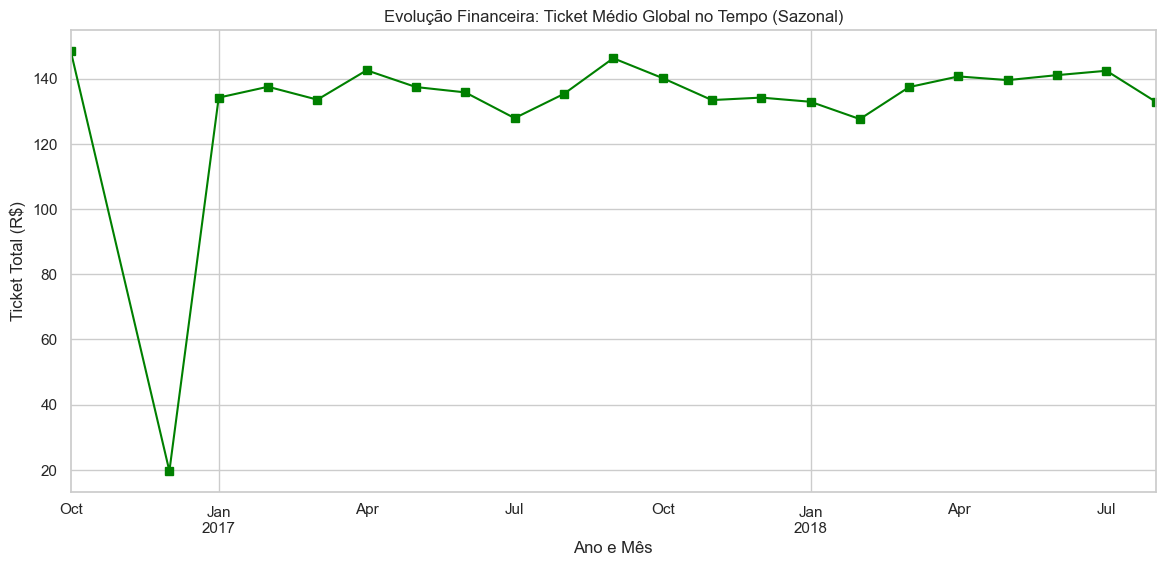

In [ ]:
if 'order_purchase_timestamp' in df.columns:
    df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
    if 'mes_ano' not in df.columns:
        df['mes_ano'] = df['order_purchase_timestamp'].dt.to_period('M')
    df['ticket_total'] = df['price'] + df['freight_value']
    ticket_evolucao = df.groupby('mes_ano')['ticket_total'].mean()

    plt.figure(figsize=(14, 6))
    ticket_evolucao.plot(kind='line', marker='s', color='green')
    plt.title('Evolução Financeira: Ticket Médio Global no Tempo (Sazonal)')
    plt.ylabel('Ticket Total (R$)')
    plt.xlabel('Ano e Mês')
    plt.savefig('results/19_evolucao_ticket_total.png', bbox_inches='tight')
    plt.show()

# Parte 2. O Comportamento do Consumidor

## 2.1 Evolução de Vendas no Tempo

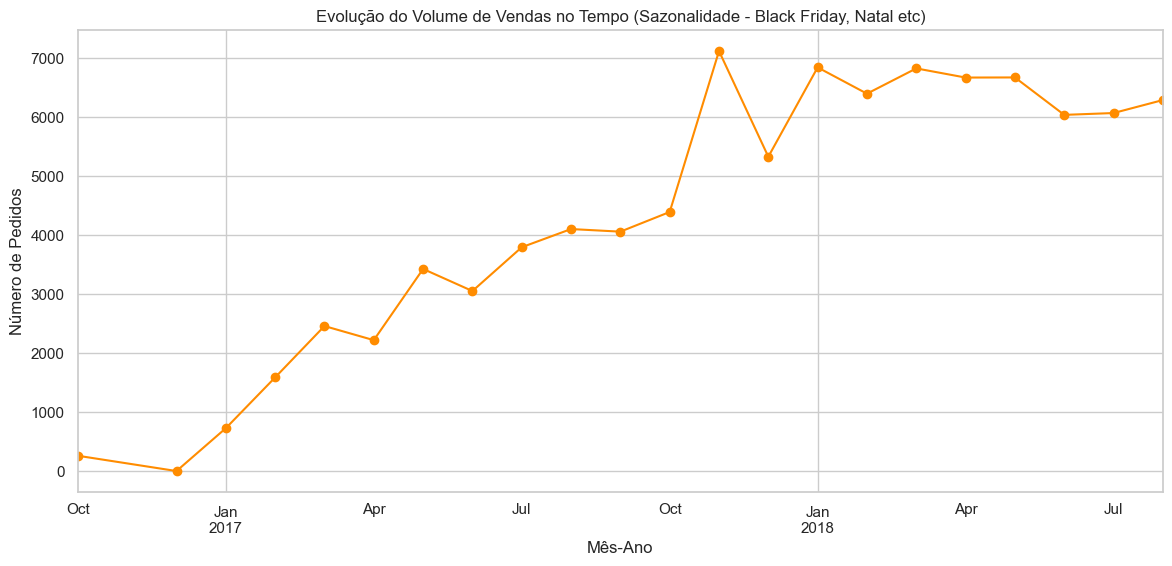

In [ ]:
# Extraindo datas e gerando sazonalidade
if 'order_purchase_timestamp' in df.columns:
    df['order_purchase_timestamp'] = pd.to_datetime(df['order_purchase_timestamp'])
    df['mes_ano'] = df['order_purchase_timestamp'].dt.to_period('M')
    vendas_mes = df.groupby('mes_ano')['order_id'].nunique()

    plt.figure(figsize=(14, 6))
    vendas_mes.plot(kind='line', marker='o', color='darkorange')
    plt.title('Evolução do Volume de Vendas no Tempo (Sazonalidade - Black Friday, Natal etc)')
    plt.ylabel('Número de Pedidos')
    plt.xlabel('Mês-Ano')
    plt.grid(True)
    plt.savefig('results/06_evolucao_vendas_sazonalidade.png', bbox_inches='tight')
    plt.show()

## 2.2 Sazonalidades Específicas

In [6]:
if 'order_purchase_timestamp' in df.columns and 'product_category_name' in df.columns:
    df['mes'] = df['order_purchase_timestamp'].dt.month
    df['ano'] = df['order_purchase_timestamp'].dt.year
    
    # Dia das crianças (Outubro) - Categoria Brinquedos
    brinquedos_outubro = df[(df['product_category_name'] == 'brinquedos') & (df['mes'] == 10)].groupby('ano')['order_id'].nunique()
    print("\nVendas de Brinquedos em Outubro (Dia das Crianças):\n", brinquedos_outubro)
    
    # Dia das Mães (Maio) vs Dia dos Pais (Agosto)
    vendas_maio = df[df['mes'] == 5]['order_id'].nunique()
    vendas_agosto = df[df['mes'] == 8]['order_id'].nunique()
    print(f"\nImpacto Geral: Maio (Mães) = {vendas_maio} pedidos | Agosto (Pais) = {vendas_agosto} pedidos")


Vendas de Brinquedos em Outubro (Dia das Crianças):
 ano
2016     21
2017    271
Name: order_id, dtype: int64

Impacto Geral: Maio (Mães) = 10092 pedidos | Agosto (Pais) = 10385 pedidos


## 2.3 Janelas Comerciais Ótimas

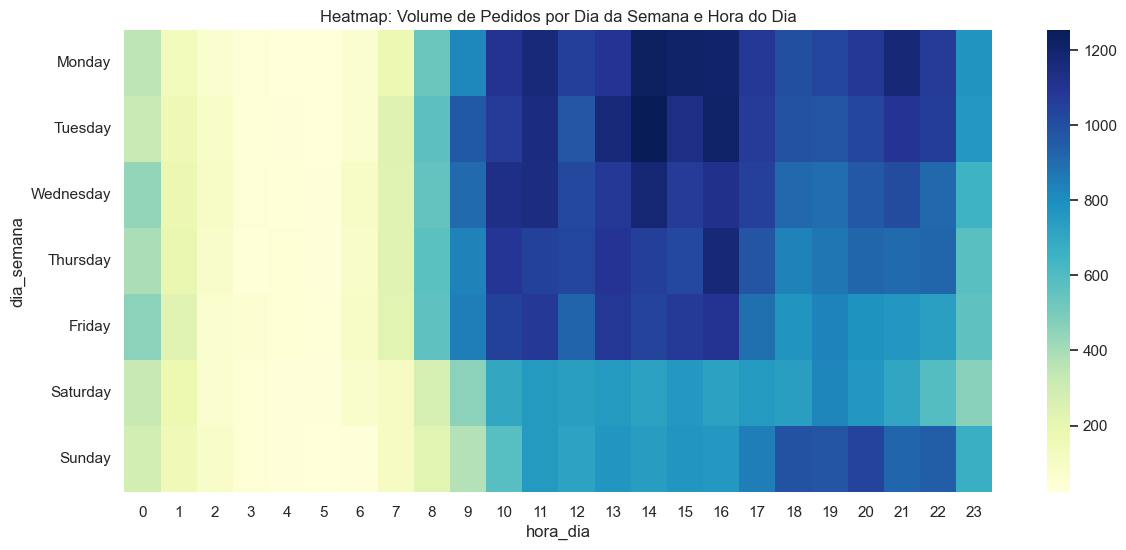

In [ ]:
# Heatmap: Dia da Semana x Hora do Dia
if 'order_purchase_timestamp' in df.columns:
    df['dia_semana'] = df['order_purchase_timestamp'].dt.day_name()
    df['hora_dia'] = df['order_purchase_timestamp'].dt.hour

    heatmap_data = pd.crosstab(df['dia_semana'], df['hora_dia'])
    dias_ordenados = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
    heatmap_data = heatmap_data.reindex(dias_ordenados)

    plt.figure(figsize=(14, 6))
    sns.heatmap(heatmap_data, cmap='YlGnBu', annot=False)
    plt.title('Heatmap: Volume de Pedidos por Dia da Semana e Hora do Dia')
    plt.savefig('results/07_heatmap_dia_hora_vendas.png', bbox_inches='tight')
    plt.show()

## 2.4 Tipos de Pagamento e Dinâmica de Parcelamento

In [8]:
if 'payment_type' in df.columns and 'payment_installments' in df.columns:
    plt.figure(figsize=(14, 6))

    plt.subplot(1, 2, 1)
    df['payment_type'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=sns.color_palette('pastel'))
    plt.title('Preferência de Formas de Pagamento')
    plt.ylabel('')

    plt.subplot(1, 2, 2)
    sns.countplot(data=df[df['payment_type'] == 'credit_card'], x='payment_installments', palette='mako')
    plt.title('Frequência de Parcelamentos (Apenas Cartões de Crédito)')
    plt.xlim(-1, 12.5)

    plt.tight_layout()
    plt.savefig('results/17_pagamento_e_parcelamento.png', bbox_inches='tight')
    plt.show()


    pagamento_uf = df.groupby(['customer_state', 'payment_type'])['order_id'].nunique().reset_index()
    pagamento_uf = pagamento_uf.sort_values(['customer_state', 'order_id'], ascending=[True, False])
    top_pagamento_uf = pagamento_uf.groupby('customer_state').head(1)
    pd.set_option('display.max_rows', 5)
    print("\nForma de pagamento mais comum por Estado:\n", top_pagamento_uf)

## 2.5 Retenção de Clientes (Customer LTV)

Freq de compras por cliente - Os clientes retornam?
order_id
1    0.970361
2    0.027283
3    0.001852
4    0.000318
5    0.000099
Name: proportion, dtype: float64


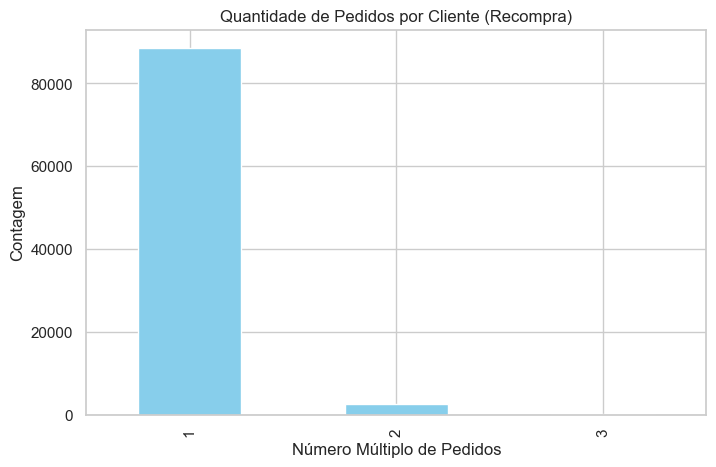


Ticket Médio da 1ª Compra: R$ 122.23
Ticket Médio das Recompras: R$ 86.41


In [ ]:
# Retenção: Clientes recorrentes vs Únicos (Customer LTV)
if 'customer_unique_id' in df.columns:
    compras_por_cliente = df.groupby('customer_unique_id')['order_id'].nunique()
    print("Freq de compras por cliente - Os clientes retornam?")
    print(compras_por_cliente.value_counts(normalize=True).head())

    plt.figure(figsize=(8, 5))
    compras_por_cliente.value_counts().head(3).plot(kind='bar', color='skyblue')
    plt.title('Quantidade de Pedidos por Cliente (Recompra)')
    plt.xlabel('Número Múltiplo de Pedidos')
    plt.ylabel('Contagem')
    plt.savefig('results/12_retencao_clientes.png', bbox_inches='tight')
    plt.show()


# Ticket cliente recorrente vs 1a compra
if 'customer_unique_id' in df.columns and 'price' in df.columns:
    df['ordem_compra'] = df.groupby('customer_unique_id')['order_purchase_timestamp'].rank(method='first').astype(int)
    ticket_primeira = df[df['ordem_compra'] == 1]['price'].mean()
    ticket_recorrente = df[df['ordem_compra'] > 1]['price'].mean()
    print(f"\nTicket Médio da 1ª Compra: R$ {ticket_primeira:.2f}")
    print(f"Ticket Médio das Recompras: R$ {ticket_recorrente:.2f}")

# Parte 3. O Produto e a Vitrine

## 3.1 Custo do Frete nas Categorias vs Rentabilidade

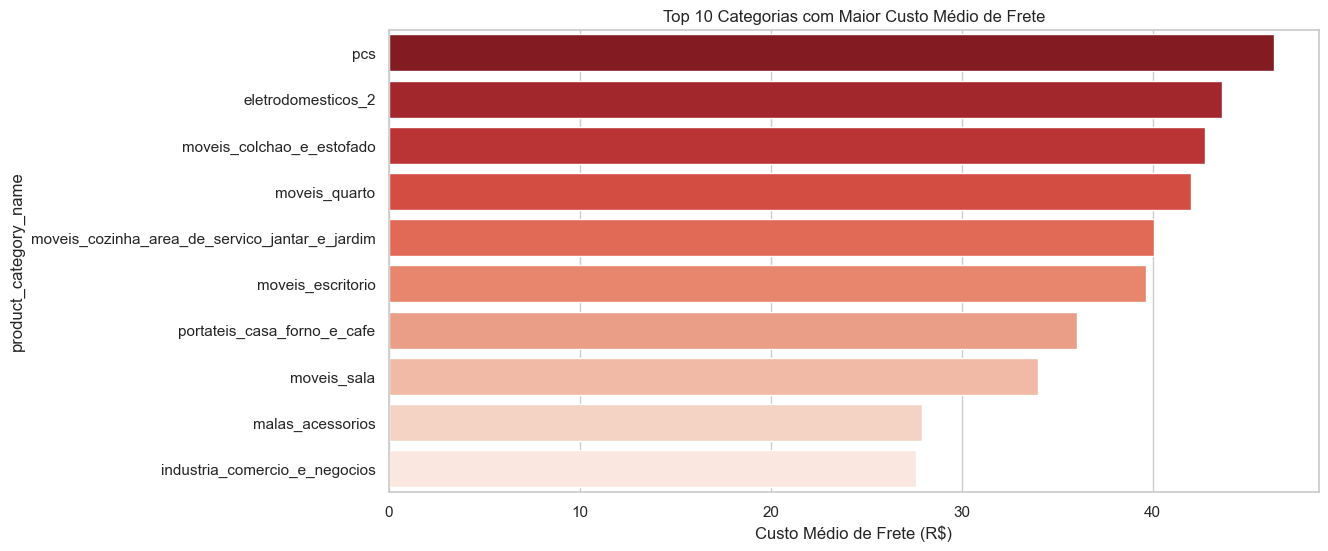

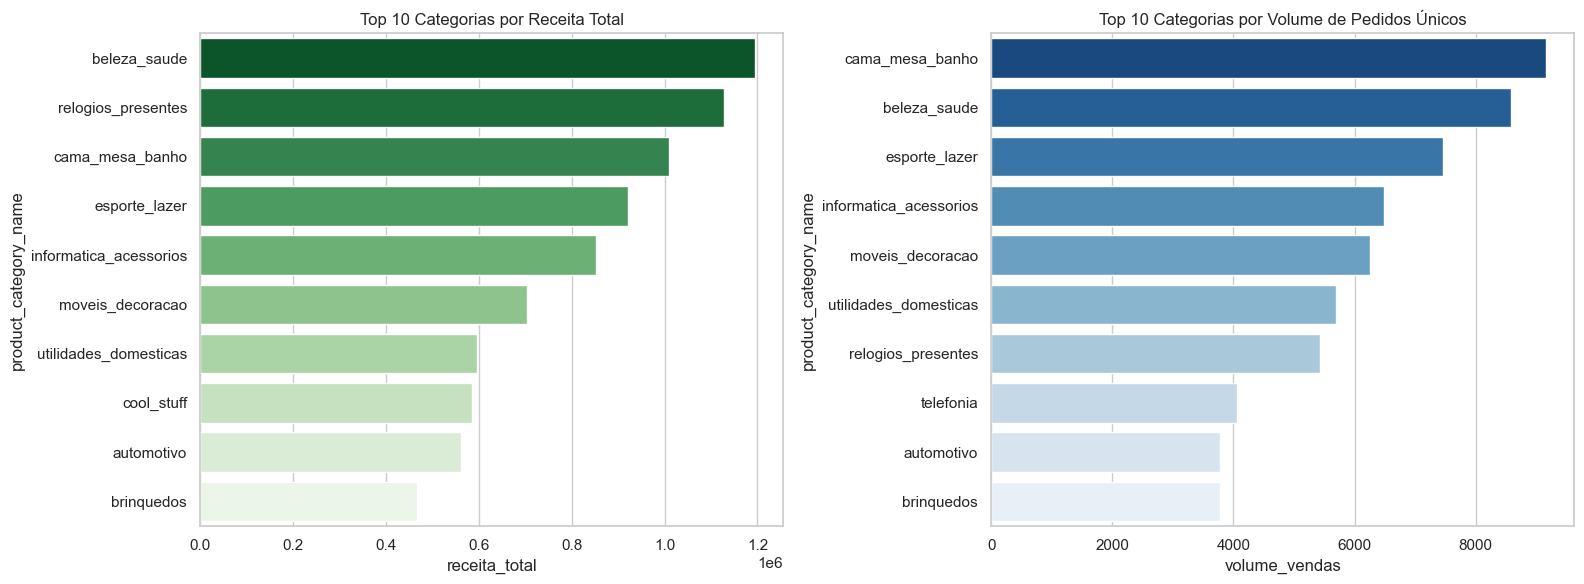

In [ ]:
# Top 10 categorias com frete mais caro (média)
if 'product_category_name' in df.columns:
    top_frete_cat = df.groupby('product_category_name')['freight_value'].mean().sort_values(ascending=False).head(10)
    plt.figure(figsize=(12, 6))
    sns.barplot(x=top_frete_cat.values, y=top_frete_cat.index, palette='Reds_r')
    plt.title('Top 10 Categorias com Maior Custo Médio de Frete')
    plt.xlabel('Custo Médio de Frete (R$)')
    plt.savefig('results/03_top10_frete_categorias.png', bbox_inches='tight')
    plt.show()

# Categorias mais rentáveis vs mais vendidas
if 'product_category_name' in df.columns and 'price' in df.columns:
    cat_stats = df.groupby('product_category_name').agg({'price': 'sum', 'order_id': 'nunique'}).reset_index()
    cat_stats.rename(columns={'price': 'receita_total', 'order_id': 'volume_vendas'}, inplace=True)

    top_receita = cat_stats.sort_values('receita_total', ascending=False).head(10)
    top_volume = cat_stats.sort_values('volume_vendas', ascending=False).head(10)

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    sns.barplot(data=top_receita, y='product_category_name', x='receita_total', ax=ax[0], palette='Greens_r')
    ax[0].set_title('Top 10 Categorias por Receita Total')

    sns.barplot(data=top_volume, y='product_category_name', x='volume_vendas', ax=ax[1], palette='Blues_r')
    ax[1].set_title('Top 10 Categorias por Volume de Pedidos Únicos')
    plt.tight_layout()
    plt.savefig('results/04_rentabilidade_vs_volume.png', bbox_inches='tight')
    plt.show()

## 3.2 O Impacto Visual (Vitrine)

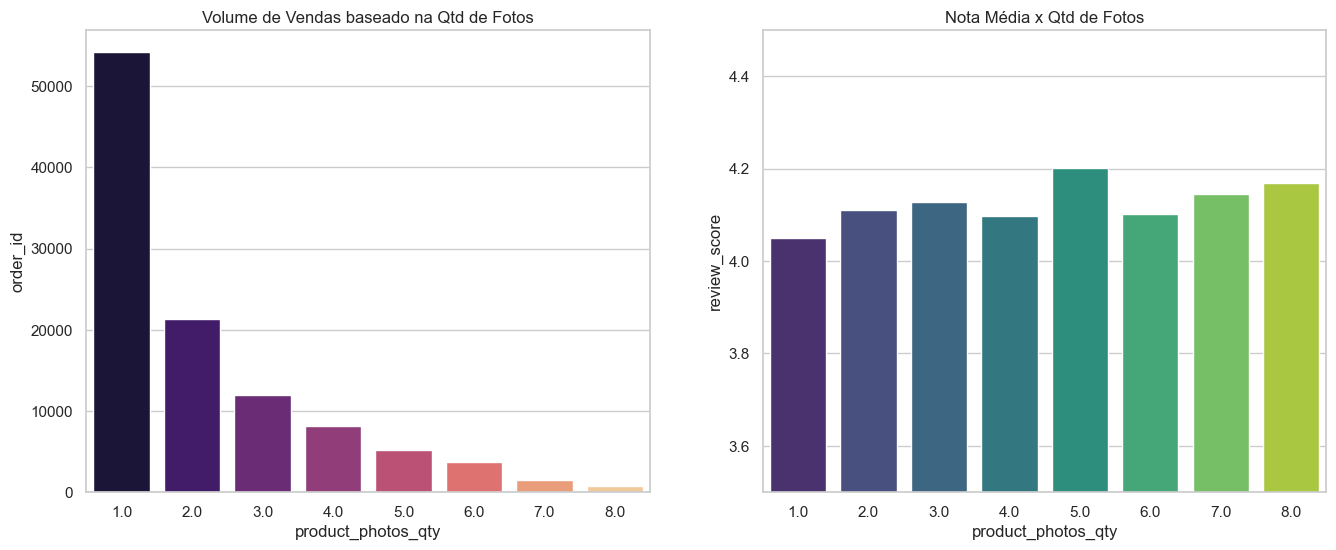

In [ ]:
# Fotos do Produto: Volume e Avaliações
if 'product_photos_qty' in df.columns and 'review_score' in df.columns:
    fotos_stats = df.groupby('product_photos_qty').agg({'order_id': 'count', 'review_score': 'mean'}).reset_index()
    fotos_stats = fotos_stats[fotos_stats['product_photos_qty'] <= 8]

    fig, ax = plt.subplots(1, 2, figsize=(16, 6))
    sns.barplot(data=fotos_stats, x='product_photos_qty', y='order_id', ax=ax[0], palette='magma')
    ax[0].set_title('Volume de Vendas baseado na Qtd de Fotos')

    sns.barplot(data=fotos_stats, x='product_photos_qty', y='review_score', ax=ax[1], palette='viridis')
    ax[1].set_title('Nota Média x Qtd de Fotos')
    ax[1].set_ylim(3.5, 4.5)
    plt.savefig('results/13_fotos_vs_vendas_e_notas.png', bbox_inches='tight')
    plt.show()

## 3.3 Consumo Específico Regional e SKUs

In [12]:
# Categoria com maior interesse por estado
if 'customer_state' in df.columns and 'product_category_name' in df.columns:
    cat_uf = df.groupby(['customer_state', 'product_category_name'])['order_id'].nunique().reset_index()
    cat_uf = cat_uf.sort_values(['customer_state', 'order_id'], ascending=[True, False])
    top_cat_uf = cat_uf.groupby('customer_state').head(1)
    print("\nCategoria mais vendida por Estado:\n", top_cat_uf)


Categoria mais vendida por Estado:
      customer_state product_category_name  order_id
10               AC         esporte_lazer         9
34               AL          beleza_saude        62
73               AM          beleza_saude        15
107              AP          beleza_saude        10
134              BA          beleza_saude       316
195              CE          beleza_saude       150
249              DF          beleza_saude       217
311              ES       cama_mesa_banho       193
366              GO          beleza_saude       206
423              MA          beleza_saude        81
477              MG       cama_mesa_banho      1107
560              MS         esporte_lazer        60
596              MT          beleza_saude        82
648              PA          beleza_saude        96
695              PB          beleza_saude        74
741              PE          beleza_saude       215
797              PI          beleza_saude        50
865              PR        

In [13]:

if 'product_id' in df.columns and 'price' in df.columns and 'product_category_name' in df.columns:
    top_produtos_volume = df.groupby('product_id').agg(
        volume=('order_id', 'nunique'),
        receita=('price', 'sum'),
        categoria_principal=('product_category_name', 'first')
    ).sort_values(by='volume', ascending=False).head(10)
    
    print("\nTop 10 Produtos Mais Vendidos (IDs Hasheados):")
    display(top_produtos_volume)


Top 10 Produtos Mais Vendidos (IDs Hasheados):


,volume,receita,categoria_principal
product_id,,,
99a4788cb24856965c36a24e339b6058,448,41330.46,cama_mesa_banho
aca2eb7d00ea1a7b8ebd4e68314663af,423,36884.40,moveis_decoracao
422879e10f46682990de24d770e7f83d,351,26523.32,ferramentas_jardim
d1c427060a0f73f6b889a5c7c61f2ac4,311,45322.56,informatica_acessorios
389d119b48cf3043d311335e499d9c6b,308,21282.89,ferramentas_jardim
53b36df67ebb7c41585e8d54d6772e08,302,37212.84,relogios_presentes
368c6c730842d78016ad823897a372db,289,20899.10,ferramentas_jardim
53759a2ecddad2bb87a079a1f1519f73,284,20234.40,ferramentas_jardim
154e7e31ebfa092203795c972e5804a6,261,6149.27,beleza_saude


# Parte 4. A Operação e os Vendedores

## 4.1 Concentração e Desempenho dos Grandes Lojistas

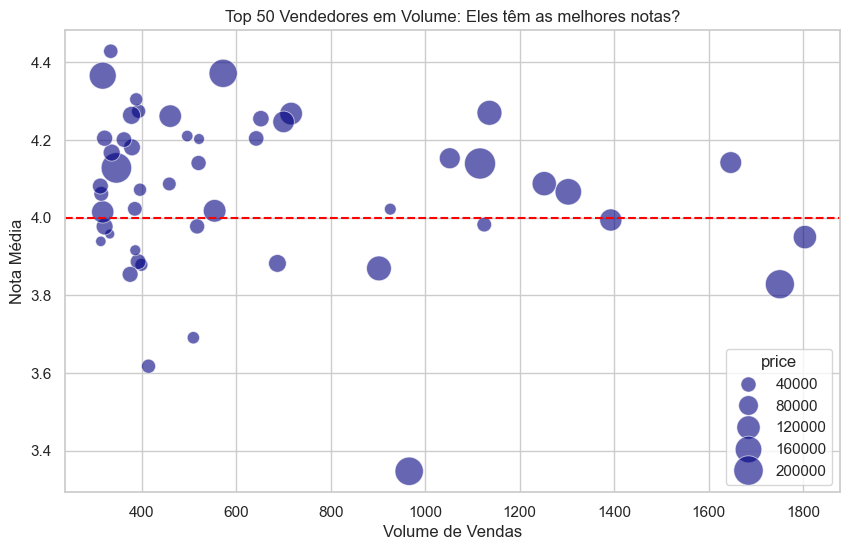


Princípio de Pareto: Os Top 20% dos vendedores correspondem a 82.3% de toda a receita.


In [ ]:
# Performance de Vendedores (Vendedores Dominantes)
if 'seller_id' in df.columns and 'review_score' in df.columns:
    seller_stats = df.groupby('seller_id').agg({'order_id': 'nunique', 'review_score': 'mean', 'price': 'sum'}).reset_index()
    top_sellers = seller_stats.sort_values('order_id', ascending=False).head(50)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=top_sellers, x='order_id', y='review_score', size='price', sizes=(50, 500), alpha=0.6, color='Navy')
    plt.title('Top 50 Vendedores em Volume: Eles têm as melhores notas?')
    plt.xlabel('Volume de Vendas')
    plt.ylabel('Nota Média')
    plt.axhline(4.0, color='red', linestyle='--')
    plt.savefig('results/14_top_vendedores.png', bbox_inches='tight')
    plt.show()


# Pareto de Vendedores
if 'seller_id' in df.columns and 'price' in df.columns:
    receita_vendedores = df.groupby('seller_id')['price'].sum().sort_values(ascending=False)
    top_20_pct = int(len(receita_vendedores) * 0.2)
    receita_top_20 = receita_vendedores.head(max(1, top_20_pct)).sum()
    receita_total = receita_vendedores.sum()
    print(f"\nPrincípio de Pareto: Os Top 20% dos vendedores correspondem a {receita_top_20/receita_total:.1%} de toda a receita.")

## 4.2 O Despacho

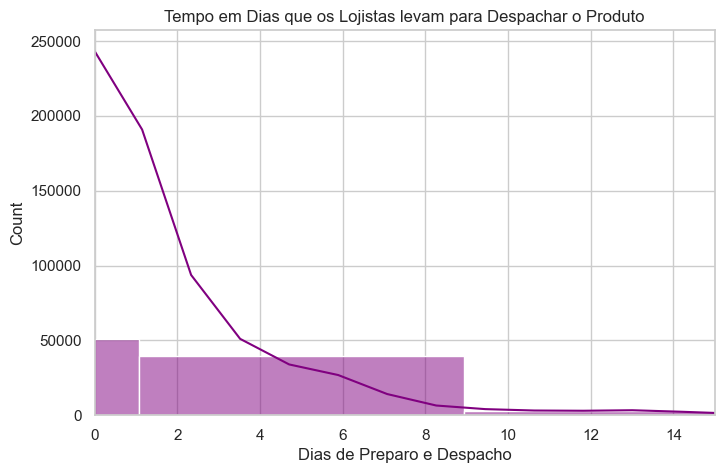

In [15]:
path_orders_raw = '../data/raw/olist_orders_dataset.csv'
if 'order_id' in df.columns:
    df_orders_raw = pd.read_csv(path_orders_raw, usecols=['order_id', 'order_approved_at', 'order_delivered_carrier_date'])
    df_dispatch = pd.merge(df[['order_id']], df_orders_raw, on='order_id', how='inner').drop_duplicates(subset=['order_id'])
    
    df_dispatch['order_approved_at'] = pd.to_datetime(df_dispatch['order_approved_at'])
    df_dispatch['order_delivered_carrier_date'] = pd.to_datetime(df_dispatch['order_delivered_carrier_date'])

    df_dispatch['seller_dispatch_days'] = (df_dispatch['order_delivered_carrier_date'] - df_dispatch['order_approved_at']).dt.days

    plt.figure(figsize=(8, 5))
    sns.histplot(df_dispatch['seller_dispatch_days'].dropna(), bins=30, kde=True, color='purple')
    plt.xlim(0, 15)
    plt.title('Tempo em Dias que os Lojistas levam para Despachar o Produto')
    plt.xlabel('Dias de Preparo e Despacho')
    plt.savefig('results/15_tempo_despacho_vendedor.png', bbox_inches='tight')
    plt.show()

# Parte 5. O Desafio Logístico e o Custo Brasil

## 5.1 O Olimpo do Ticket: Relação Preço x Frete

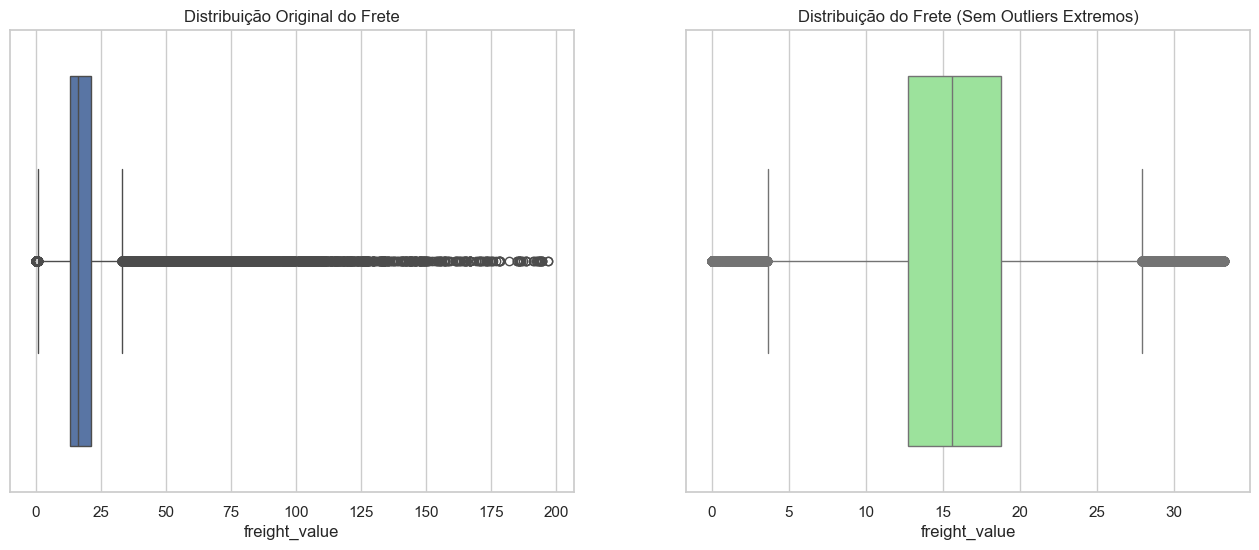

In [ ]:
# Distribuição do valor do frete e tratamento de outliers visuais
fig, ax = plt.subplots(1, 2, figsize=(16, 6))
sns.boxplot(x=df['freight_value'], ax=ax[0])
ax[0].set_title('Distribuição Original do Frete')

# Filtrando outliers extremos para melhor visualização (Regra do IQR)
Q1 = df['freight_value'].quantile(0.25)
Q3 = df['freight_value'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
df_frete_filtrado = df[df['freight_value'] <= upper_bound]

sns.boxplot(x=df_frete_filtrado['freight_value'], ax=ax[1], color='lightgreen')
ax[1].set_title('Distribuição do Frete (Sem Outliers Extremos)')
plt.savefig('results/01_distribuicao_frete.png', bbox_inches='tight')
plt.show()

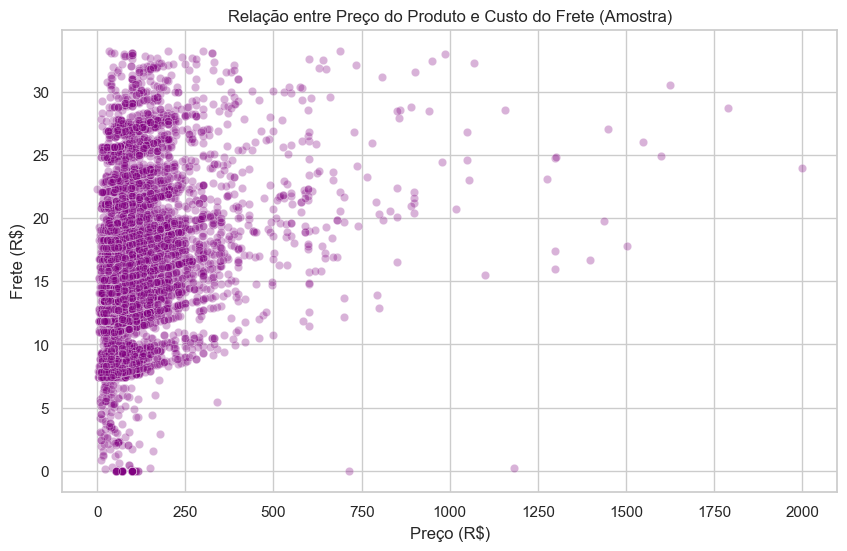

In [ ]:
# Custo do Frete vs Preço
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_frete_filtrado.sample(min(10000, len(df_frete_filtrado))), x='price', y='freight_value', alpha=0.3, color='purple')
plt.title('Relação entre Preço do Produto e Custo do Frete (Amostra)')
plt.xlabel('Preço (R$)')
plt.ylabel('Frete (R$)')
plt.savefig('results/02_frete_vs_preco.png', bbox_inches='tight')
plt.show()

## 5.2 O Peso Físico do Frete e Rotas Tensionadas

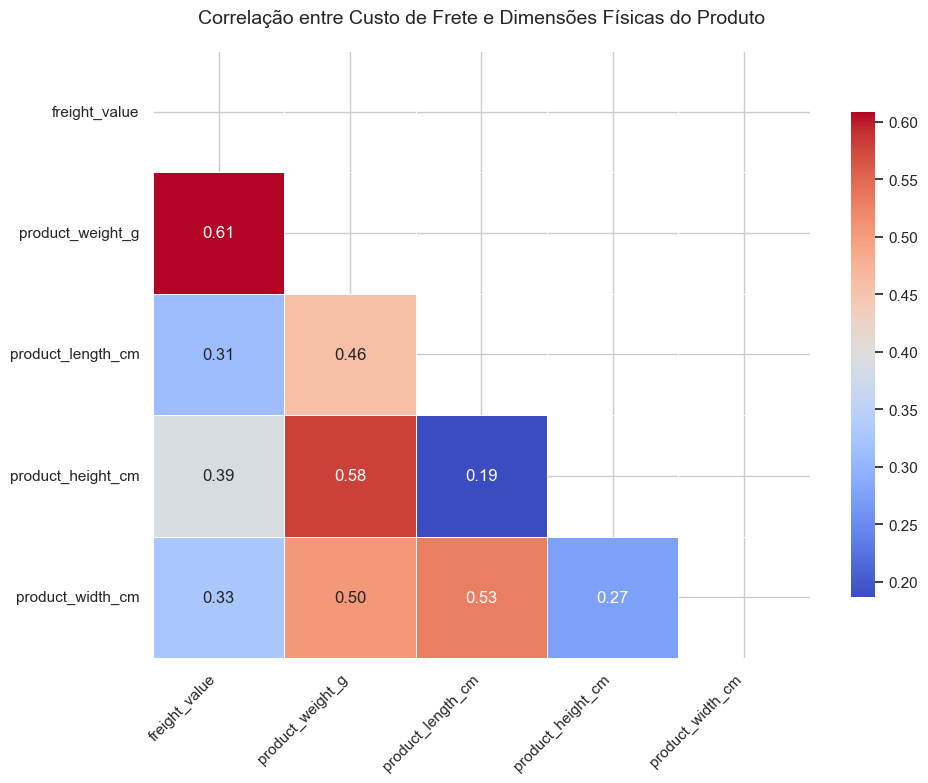

In [ ]:
# Correlação do Frete com características físicas do produto
path_products = '../data/raw/olist_products_dataset.csv'
df_products = pd.read_csv(path_products, usecols=[
    'product_id', 'product_weight_g', 'product_length_cm', 
    'product_height_cm', 'product_width_cm'
])

if 'product_id' in df.columns and 'freight_value' in df.columns:
    df_dimensional = pd.merge(df[['product_id', 'freight_value']], df_products, on='product_id', how='inner')
    cols_fisicas = ['freight_value', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm']
    df_dimensional_clean = df_dimensional[cols_fisicas].dropna()

    if len(df_dimensional_clean) > 0:
        plt.figure(figsize=(10, 8))
        correlacao = df_dimensional_clean.corr()
        mask = np.triu(np.ones_like(correlacao, dtype=bool))

        sns.heatmap(
            correlacao, 
            mask=mask, 
            annot=True, 
            cmap='coolwarm', 
            fmt=".2f", 
            linewidths=0.5,
            cbar_kws={"shrink": .8}
        )
        plt.title('Correlação entre Custo de Frete e Dimensões Físicas do Produto', pad=20, fontsize=14)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.savefig('results/05_heatmap_correlacao_dimensoes.png', bbox_inches='tight')
        plt.show()
    else:
        print("Não há dados suficientes ou válidos nas colunas dimensionais para gerar a correlação.")

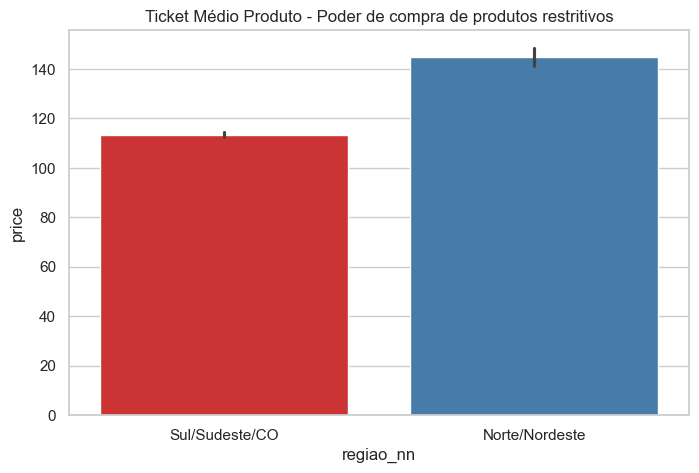

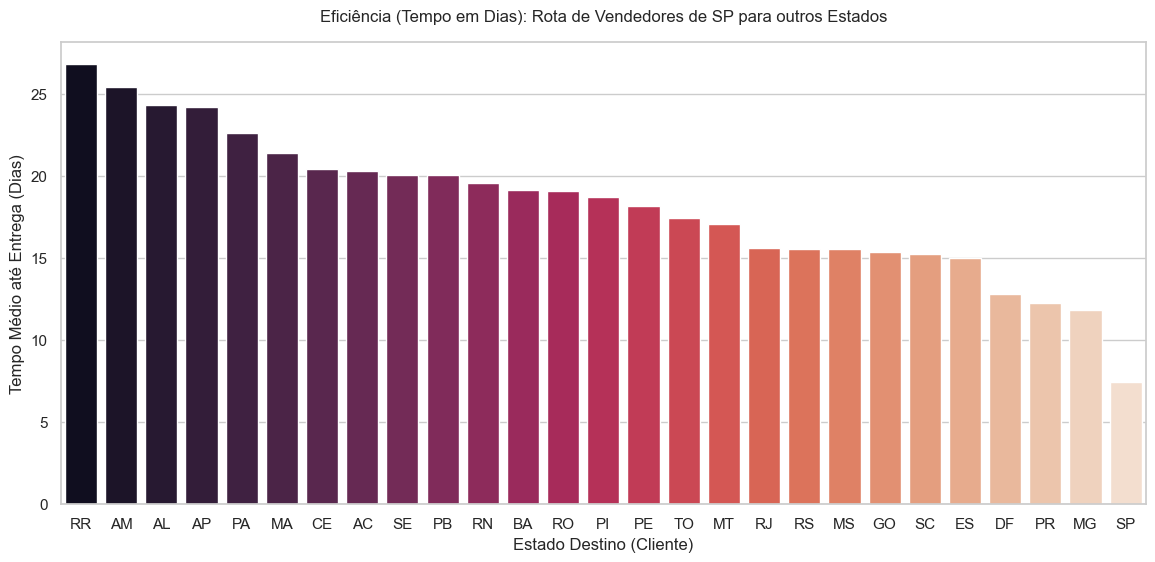

In [ ]:
if 'customer_state' in df.columns and 'price' in df.columns:
    norte_nordeste = ['AC', 'AP', 'AM', 'PA', 'RO', 'RR', 'TO', 'AL', 'BA', 'CE', 'MA', 'PB', 'PE', 'PI', 'RN', 'SE']
    df['regiao_nn'] = df['customer_state'].apply(lambda x: 'Norte/Nordeste' if x in norte_nordeste else 'Sul/Sudeste/CO')

    plt.figure(figsize=(8, 5))
    sns.barplot(data=df, x='regiao_nn', y='price', estimator=np.mean, palette='Set1')
    plt.title('Ticket Médio Produto - Poder de compra de produtos restritivos')
    plt.savefig('results/18_ticket_medio_norte_nordeste.png', bbox_inches='tight')
    plt.show()

if 'customer_state' in df.columns and 'seller_state' in df.columns and 'tempo_entrega_dias' in df.columns:
    df_rotas_clean = df[['order_id', 'customer_state', 'seller_state', 'tempo_entrega_dias']].drop_duplicates()
    
    sp_routes = df_rotas_clean[df_rotas_clean['seller_state'] == 'SP']\
                    .groupby('customer_state')['tempo_entrega_dias']\
                    .mean().sort_values(ascending=False).reset_index()
    
    plt.figure(figsize=(14, 6))
    sns.barplot(data=sp_routes, x='customer_state', y='tempo_entrega_dias', palette='rocket')
    plt.title('Eficiência (Tempo em Dias): Rota de Vendedores de SP para outros Estados', pad=15)
    plt.xlabel('Estado Destino (Cliente)')
    plt.ylabel('Tempo Médio até Entrega (Dias)')
    plt.savefig('results/10_rotas_sp_outros_estados.png', bbox_inches='tight')
    plt.show()

# Parte 6. Impacto Logístico na Satisfação

## 6.1 A Ruína Irreversível do Atraso

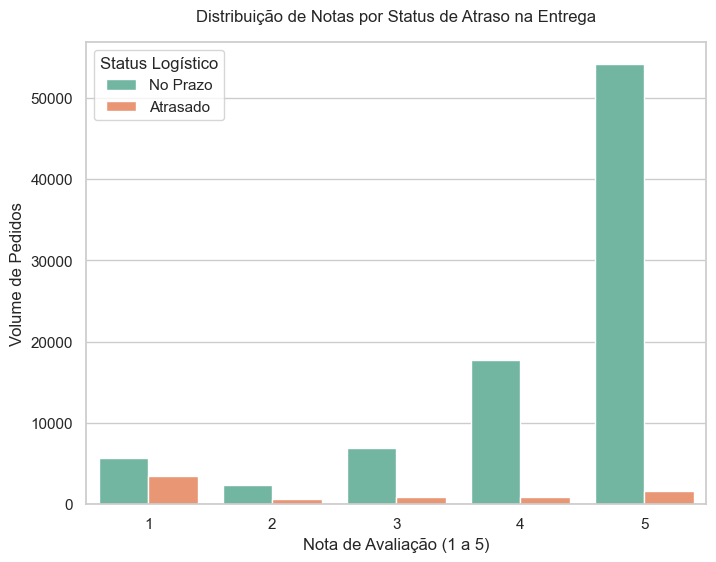

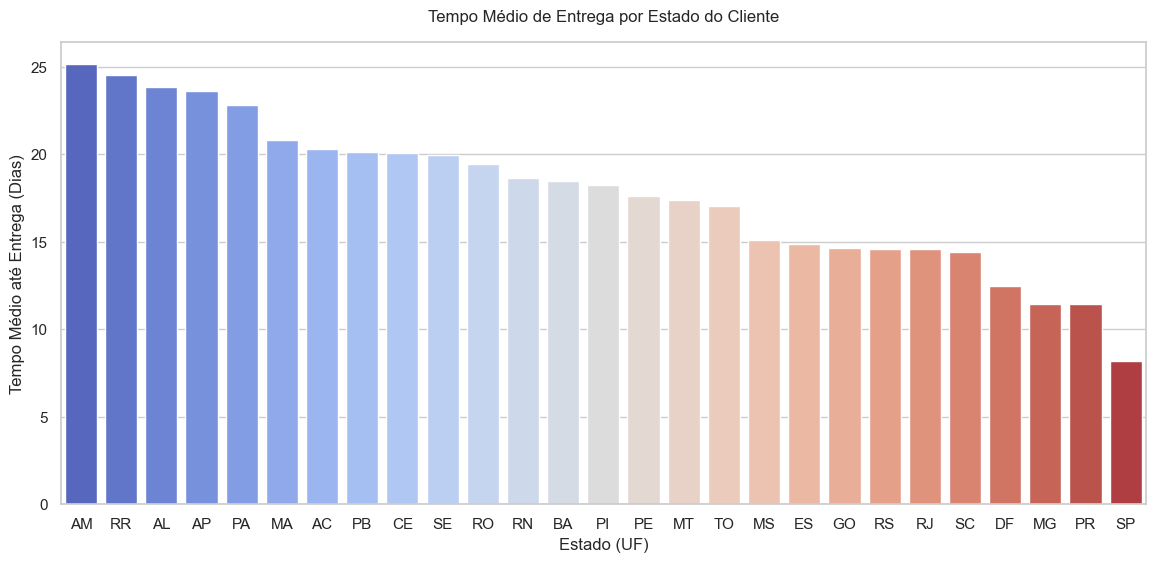

In [ ]:
# Impacto Logístico na Avaliação (Utilizando Super Dataset)
if 'atraso_entrega' in df.columns and 'review_score' in df.columns:
    df_delay_review = df[['order_id', 'atraso_entrega', 'review_score']].drop_duplicates(subset=['order_id']).copy()
    df_delay_review['review_score'] = df_delay_review['review_score'].round().astype(int)
    
    plt.figure(figsize=(8, 6))
    sns.countplot(data=df_delay_review, x='review_score', hue='atraso_entrega', palette='Set2')
    plt.title('Distribuição de Notas por Status de Atraso na Entrega', pad=15)
    plt.legend(title='Status Logístico', labels=['No Prazo', 'Atrasado'])
    plt.xlabel('Nota de Avaliação (1 a 5)')
    plt.ylabel('Volume de Pedidos')
    plt.savefig('results/08_notas_por_atraso.png', bbox_inches='tight')
    plt.show()
if 'customer_state' in df.columns and 'tempo_entrega_dias' in df.columns:
    estado_stats = df.groupby('customer_state')['tempo_entrega_dias'].mean().sort_values(ascending=False).reset_index()
    
    plt.figure(figsize=(14, 6))
    sns.barplot(data=estado_stats, x='customer_state', y='tempo_entrega_dias', palette='coolwarm')
    plt.title('Tempo Médio de Entrega por Estado do Cliente', pad=15)
    plt.xlabel('Estado (UF)')
    plt.ylabel('Tempo Médio até Entrega (Dias)')
    plt.savefig('results/09_tempo_entrega_estado.png', bbox_inches='tight')
    plt.show()

## 6.2 Expectativa Multivariada (OLS e Heatmaps)

Resumo OLS - Impacto Numérico no Score:
                            OLS Regression Results                            
Dep. Variable:           review_score   R-squared:                       0.104
Model:                            OLS   Adj. R-squared:                  0.104
Method:                 Least Squares   F-statistic:                     4166.
Date:                Sun, 08 Mar 2026   Prob (F-statistic):               0.00
Time:                        01:49:47   Log-Likelihood:            -1.7844e+05
No. Observations:              107576   AIC:                         3.569e+05
Df Residuals:                  107572   BIC:                         3.569e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                         coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------

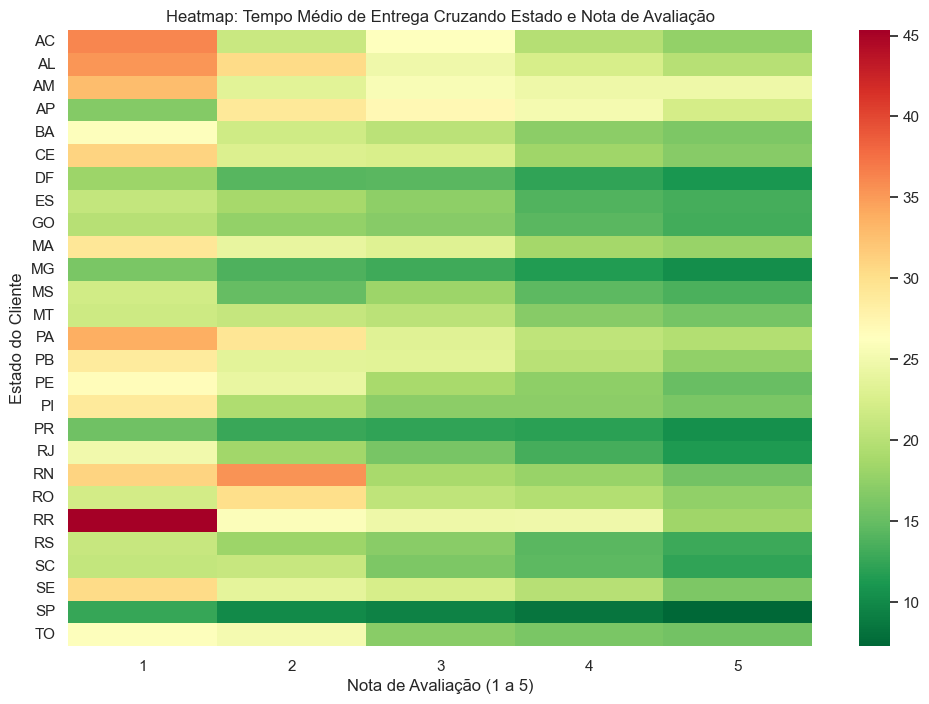

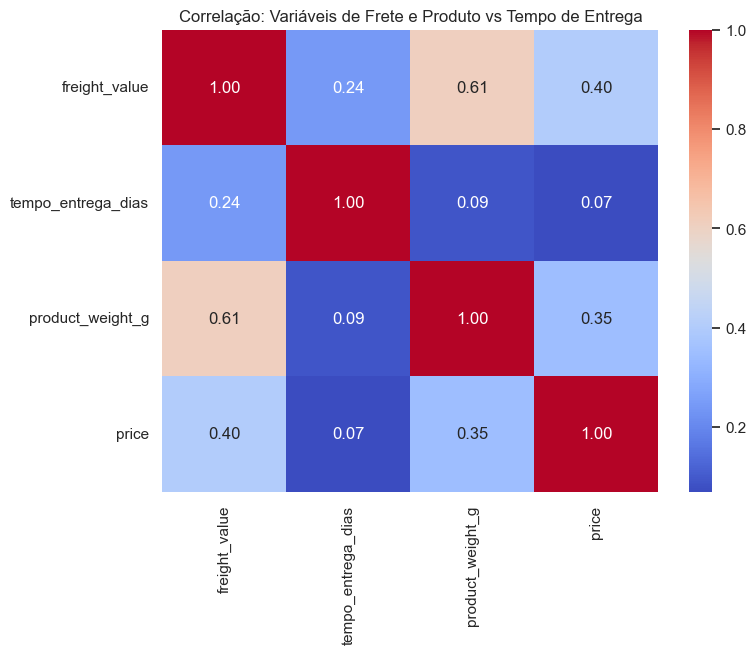

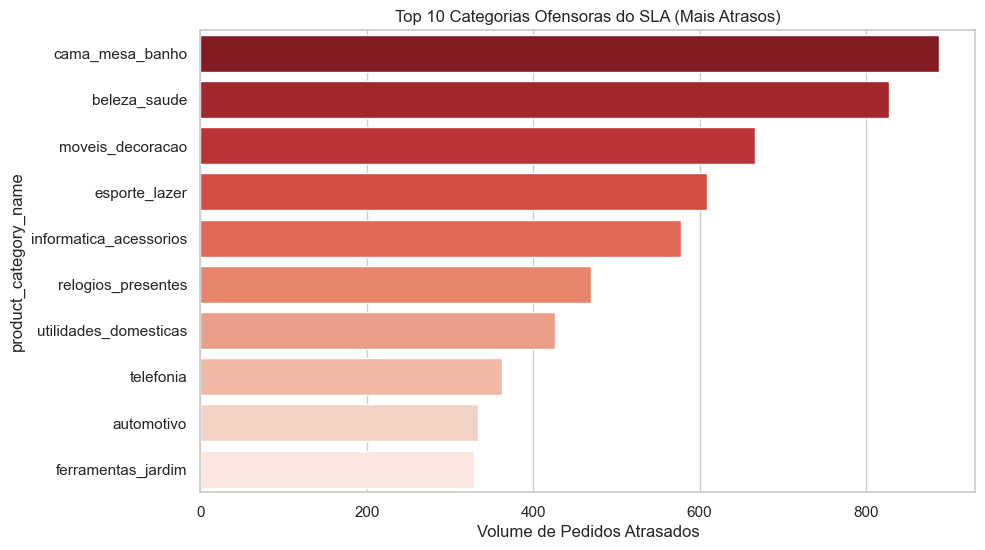


% de vendas interestaduais em avaliações baixas (1-2): 70.1%
% de vendas interestaduais em avaliações altas (4-5): 62.2%


In [ ]:
import statsmodels.api as sm

# Removendo nulos para modelagem
cols_ols = ['freight_value', 'price', 'tempo_entrega_dias']
if all(c in df.columns for c in cols_ols) and 'review_score' in df.columns:
    df_ols = df[cols_ols + ['review_score']].dropna()
    X = df_ols[cols_ols]
    X = sm.add_constant(X)
    Y = df_ols['review_score']

    model = sm.OLS(Y, X).fit()
    print("Resumo OLS - Impacto Numérico no Score:")
    print(model.summary())



# Heatmap Nota x Estado x Tempo de entrega
if 'customer_state' in df.columns and 'review_score' in df.columns and 'tempo_entrega_dias' in df.columns:
    df_hm = df.copy()
    df_hm['review_score'] = df_hm['review_score'].round().astype(int)
    heatmap_data_estado_nota = df_hm.groupby(['customer_state', 'review_score'])['tempo_entrega_dias'].mean().unstack()
    plt.figure(figsize=(12, 8))
    sns.heatmap(heatmap_data_estado_nota, cmap='RdYlGn_r', annot=False)
    plt.title('Heatmap: Tempo Médio de Entrega Cruzando Estado e Nota de Avaliação')
    plt.xlabel('Nota de Avaliação (1 a 5)')
    plt.ylabel('Estado do Cliente')
    plt.savefig('results/20_heatmap_tempo_estado_nota.png', bbox_inches='tight')
    plt.show()

# Heatmap Frete x Tempo_Entrega
if 'freight_value' in df.columns and 'tempo_entrega_dias' in df.columns:
    try:
        # Carregando product_weight_g já que não está contido globalmente no Super Dataset padrão
        df_prod_temp = pd.read_csv('../data/raw/olist_products_dataset.csv', usecols=['product_id', 'product_weight_g'])
        if 'product_id' in df.columns:
            df_merge_corr = pd.merge(df[['freight_value', 'tempo_entrega_dias', 'price', 'product_id']], df_prod_temp, on='product_id', how='left')
            corr_frete_tempo = df_merge_corr[['freight_value', 'tempo_entrega_dias', 'product_weight_g', 'price']].corr()
        else:
            raise Exception("Sem product_id para merge")
    except Exception as e:
        corr_frete_tempo = df[['freight_value', 'tempo_entrega_dias', 'price']].corr()

    plt.figure(figsize=(8, 6))
    sns.heatmap(corr_frete_tempo, annot=True, cmap='coolwarm', fmt='.2f')
    plt.title('Correlação: Variáveis de Frete e Produto vs Tempo de Entrega')
    plt.savefig('results/21_heatmap_frete_tempo.png', bbox_inches='tight')
    plt.show()

# Categorias ofensoras de Atraso Logístico (Especial Móveis)
if 'product_category_name' in df.columns and 'atraso_entrega' in df.columns:
    cat_atraso = df[df['atraso_entrega'] == True]['product_category_name'].value_counts().head(10)
    
    plt.figure(figsize=(10, 6))
    sns.barplot(x=cat_atraso.values, y=cat_atraso.index, palette='Reds_r')
    plt.title('Top 10 Categorias Ofensoras do SLA (Mais Atrasos)')
    plt.xlabel('Volume de Pedidos Atrasados')
    plt.savefig('results/22_ofensores_atraso_moveis.png', bbox_inches='tight')
    plt.show()

# Vendedores ruins vendem para longe?
if 'review_score' in df.columns and 'seller_state' in df.columns and 'customer_state' in df.columns:
    df['rota_interestadual'] = df['seller_state'] != df['customer_state']
    perc_longe_nota_baixa = df[df['review_score'] <= 2]['rota_interestadual'].mean()
    perc_longe_nota_alta = df[df['review_score'] >= 4]['rota_interestadual'].mean()
    print(f"\n% de vendas interestaduais em avaliações baixas (1-2): {perc_longe_nota_baixa:.1%}")
    print(f"% de vendas interestaduais em avaliações altas (4-5): {perc_longe_nota_alta:.1%}")

# Parte 7. Provas Textuais e Comportamentais Avançadas

In [ ]:
# Verificando menções de atraso nos comentários
path_reviews_raw = '../data/raw/olist_order_reviews_dataset.csv'
if 'order_id' in df.columns and 'review_score' in df.columns:
    df_reviews_raw = pd.read_csv(path_reviews_raw, usecols=['order_id', 'review_comment_message'])
    df_nlp = pd.merge(df[['order_id', 'review_score']], df_reviews_raw, on='order_id', how='inner').dropna(subset=['review_comment_message'])

    if len(df_nlp) > 0:
        df_nlp['menciona_atraso'] = df_nlp['review_comment_message'].str.contains('atraso|demora', case=False, na=False)

        print("Proporção que menciona atraso/demora no texto:")
        print(df_nlp['menciona_atraso'].value_counts(normalize=True))

        print("\nMédia da nota QUANDO MENCIONA atraso:", df_nlp[df_nlp['menciona_atraso']]['review_score'].mean())
        print("Média da nota QUANDO NÃO MENCIONA:", df_nlp[~df_nlp['menciona_atraso']]['review_score'].mean())

        print("\nAmostras Reais de Comentários mencionando Atraso:")
        display(df_nlp[df_nlp['menciona_atraso']].sample(min(5, len(df_nlp[df_nlp['menciona_atraso']]))))

Proporção que menciona atraso/demora no texto:
menciona_atraso
False    0.981138
True     0.018862
Name: proportion, dtype: float64

Média da nota QUANDO MENCIONA atraso: 2.4707602339181287
Média da nota QUANDO NÃO MENCIONA: 3.6681356897663053

Amostras Reais de Comentários mencionando Atraso:


,order_id,review_score,review_comment_message,menciona_atraso
83403,8deef23d1fd8c6c5f9f3d449baec0648,1.0,"Comprei 4 itens, porém, chegou somente 1, o pi...",True
62113,d7362aa5fe91fbcde99a34eb3f592a36,1.0,"atraso na entrega da mercadoria,não cumpre pra...",True
12012,840d7cc10efae8ba460cc8ea84f1b6db,1.0,"Comprei o produto mais não foi entregue, toda ...",True
80909,302e20550af8f4aa30223f3cabcc14c0,2.0,demora com a entrega,True
28683,b52314e04baaecb498e1446be2dcabee,1.0,"falta de respeito pelo consumidor, não dão sat...",True


### Atraso impede recompra? (Customer_unique_id que atrasou a 1a vez e recomprou)

In [23]:
if 'customer_unique_id' in df.columns and 'atraso_entrega' in df.columns:
    compras_por_cliente = df.groupby('customer_unique_id').agg(
        qtd_compras=('order_id', 'nunique'),
        teve_atraso=('atraso_entrega', lambda x: 1 if (x == True).any() else 0)
    ).reset_index()
    
    reten_atraso = compras_por_cliente[compras_por_cliente['teve_atraso'] == 1]['qtd_compras'].apply(lambda x: 'Recomprou' if x > 1 else 'Não Recomprou').value_counts(normalize=True)
    reten_no_prazo = compras_por_cliente[compras_por_cliente['teve_atraso'] == 0]['qtd_compras'].apply(lambda x: 'Recomprou' if x > 1 else 'Não Recomprou').value_counts(normalize=True)
    
    print("Retenção quando houve atraso prévio:\n", reten_atraso)
    print("\nRetenção quando entregue no prazo:\n", reten_no_prazo)

Retenção quando houve atraso prévio:
 qtd_compras
Não Recomprou    0.955127
Recomprou        0.044873
Name: proportion, dtype: float64

Retenção quando entregue no prazo:
 qtd_compras
Não Recomprou    0.97171
Recomprou        0.02829
Name: proportion, dtype: float64


# Parte 8. Conclusões Numéricas de Segmentação

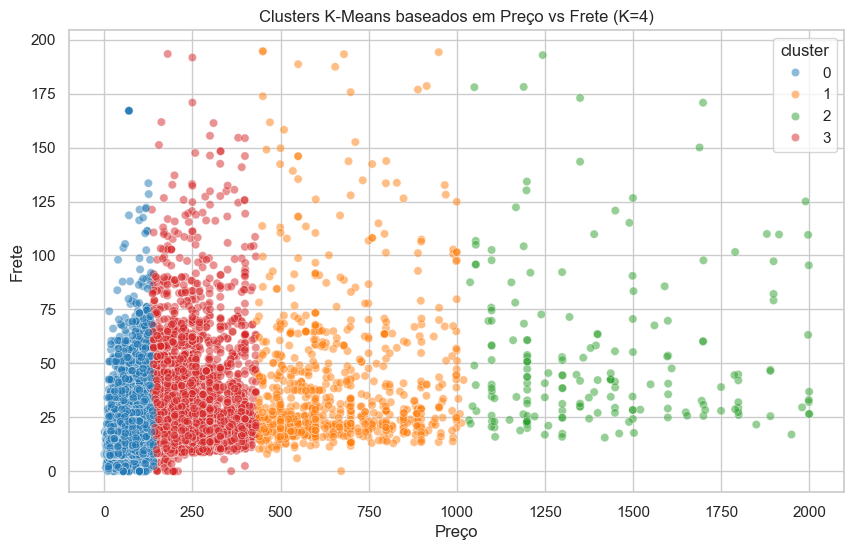

In [ ]:
# K-Means Cluster em Variáveis Monetárias e de Tempo
from sklearn.cluster import KMeans

cols_kmeans = ['freight_value', 'price']
if 'delivery_days' in df.columns:
    cols_kmeans.append('delivery_days')

df_cluster = df[cols_kmeans].dropna()
if len(df_cluster) > 0:
    df_sample = df_cluster.sample(n=min(30000, len(df_cluster)), random_state=42)
    kmeans = KMeans(n_clusters=4, random_state=42)
    df_sample['cluster'] = kmeans.fit_predict(df_sample)

    plt.figure(figsize=(10, 6))
    sns.scatterplot(data=df_sample, x='price', y='freight_value', hue='cluster', palette='tab10', alpha=0.5)
    plt.title('Clusters K-Means baseados em Preço vs Frete (K=4)')
    plt.xlabel('Preço')
    plt.ylabel('Frete')
    plt.savefig('results/11_kmeans_frete_preco.png', bbox_inches='tight')
    plt.show()


# Conclusão e Pipeline para Machine Learning

Com base nas análises exploratórias executadas ao longo do material, podemos sintetizar os 10 grandes Insights e destilar as seguintes oportunidades para modelos preditivos que gerarão alavancas reais de ROI para a Olist:

### 1. Modelo Preditivo de Churn de Carrinho (Logístico)
**Problema:** Alta taxa de abandono no Norte/Nordeste por conta de fretes elevados.
**Proposta:** Modelo de classificação em Real-Time (Random Forest / XGBoost) baseando-se no cruzamento CEP Usuário x Peso/Cubagem para disparar cupons automáticos quando a $Probabilidade(Abandono) > 85\%$.

### 2. CLV (Customer Lifetime Value) Regionalizado
**Problema:** Custos de Ads com ROI baixo em regiões com alta insatisfação logística.
**Proposta:** Regressão linear estimando o ticket vitalício do cliente nas primeiras horas após a primeira compra e penalizando o score se o hub de distribuição estiver estressado (SLA comprometido).

### 3. Recomendação Estratégica de Cross-Selling por CEP
**Problema:** Esvaziamento no volume da cesta em compras Norte/Nordeste.
**Proposta:** Sistema de recomendação filtrada por cubagem: Sugerir adicionais leves, de alta densidade de preço ("Relógios & Beleza"), que encaixam na mesma faixa volumétrica do frete principal, diluindo a barreira logística.

### 4. Detector de Anomalias em Trânsito (Fricção de SAC)
**Problema:** Fricção severa com avaliação 1 Estrela e clientes insatisfeitos com atraso surpresa.
**Proposta:** Anomaly Detection nos Logs de Tracker apontando hubs lentos. Se o pacote ficar retido, um alerta proativo notifica a central do SAC.

### 5. Otimização de Mix de Estoque para CD Avançado
**Problema:** Indisponibilidade regional agilizada.
**Proposta:** K-Means multivariado de Demanda Latente (Onde buscaram e saíram por frete caro?) vs Malha Logística Rápida. Foco metodológico para abrir um Centro de Distribuição fora de São Paulo com categorias específicas.